# Notebook 3 — Chemical Fingerprinting & Source-Receptor Validation

**Prerequisite**: Run Notebook 2 first. All files are loaded from the `data_prep/` folder.

---
### What is Chemical Fingerprinting and why do we need it?

The Gaussian Plume transport matrix T from Notebook 2 is a **model prediction**.
It uses physics equations that assume flat terrain, uniform mixing, and steady wind.
Bangalore has buildings, lakes, valleys and traffic patterns the model does not know about.

**Fingerprinting is the empirical reality check.**
Instead of trusting the model, we look at the actual sensor data and ask:

> *When the wind at station j points toward station i, does station i's PM2.5 go up?*

If yes → the model transport link is real.
If no → the link is a model artefact, not a physical pathway.

---
### Three steps in this notebook

```
Step 1 — Wind-cone pair analysis
  For each (source j → receptor i) pair:
    Find timestamps where wind at j falls within ±30° of the compass bearing to i
    Call these "transport-active" windows

Step 2 — Enrichment ratio
  E(j→i) = median PM2.5 at i during transport-active windows
            ÷
            median PM2.5 at i during all other windows
  E > 1.25 → j genuinely raises i's pollution when wind blows that way
  E ≈ 1.0  → no real transport signal

Step 3 — Statistical validation (Mann-Whitney U test)
  Is the enrichment real or just random noise?
  p < 0.05 → the difference is statistically significant

Step 4 — Compare with T matrix
  Scatter: T_mean[i,j] vs E[i,j]  — do model and data agree?
```


## Block 1 — Matplotlib Setup (IEEE Style)

In [42]:
# 1. Importing style libraries
import matplotlib.pyplot as plt
import scienceplots

# 2. Configuring matplotlib for IEEE publication style
plt.style.use(["science", "no-latex"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "mathtext.default": "regular",
        "text.usetex": False,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.4,
        "xtick.direction": "in",
        "ytick.direction": "in",
    }
)

## Block 2 — Imports & Load Phase 2 Outputs

In [43]:
# 3. Importing all core libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
from scipy import stats
from tqdm import tqdm

# 4. Configuring file paths — data_prep/ is where Notebook 2 saved its outputs
NOTEBOOK_DIR = Path.cwd()
PHASE2_IN = NOTEBOOK_DIR / "data_prep"
PHASE3_OUT = NOTEBOOK_DIR / "chemical_fingerprinting"
PHASE3_OUT.mkdir(exist_ok=True)

# 5. Loading all outputs from Notebook 2
T_tensor = np.load(PHASE2_IN / "T_tensor.npy")
C_wide = pd.read_parquet(PHASE2_IN / "C_matrix.parquet")
WS_wide = pd.read_parquet(PHASE2_IN / "WS_matrix.parquet")
WD_wide = pd.read_parquet(PHASE2_IN / "WD_matrix.parquet")
meta_df = pd.read_parquet(PHASE2_IN / "meta.parquet")

In [44]:
STATION_NAMES = C_wide.columns.tolist()
N = len(STATION_NAMES)
times = C_wide.index
short_names = [s[:10] for s in STATION_NAMES]

# 6. Loading station coordinates — needed for the network map at the end
stations_df = pd.read_csv(
    NOTEBOOK_DIR.parents[2] / "backend" / "data" / "raw" / "stations.csv"
)
LATS = stations_df.set_index("station_name").loc[STATION_NAMES, "latitude"].values
LONS = stations_df.set_index("station_name").loc[STATION_NAMES, "longitude"].values

display(
    pd.DataFrame(
        {
            "T_tensor shape": [T_tensor.shape],
            "C_wide shape": [C_wide.shape],
            "Stations": [N],
            "Timestamps": [len(times)],
            "Station list": [", ".join(STATION_NAMES)],
        }
    )
)

,T_tensor shape,C_wide shape,Stations,Timestamps,Station list
0,"(35040, 7, 7)","(35040, 7)",7,35040,"BTMLayout, Hebbal, Jigani, KasturiNagar, RvceM..."


## Block 3 — Configuration

In [45]:
# 7. Setting all tunable parameters in one place so they are easy to adjust
CONE_DEG             = 30.0   # wind must point within ±30° of the bearing to i
MIN_ACTIVE_WINDOWS   = 20     # need at least 20 active timestamps for a reliable enrichment
ENRICHMENT_THRESHOLD = 1.25   # 25% above baseline = meaningful source signal
ALPHA                = 0.05   # p-value cutoff for Mann-Whitney significance test

## Block 4 — Pre-compute Bearings & Distances

`bearing(j → i)` is the compass direction you would need to travel FROM station j TO reach station i.

If wind at j blows in that exact direction, it carries j's pollution straight to i.


In [46]:
# 8. Haversine distance — great-circle distance between two lat/lon points [km]
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δφ = np.radians(lat2 - lat1)
    Δλ = np.radians(lon2 - lon1)
    a = np.sin(Δφ / 2) ** 2 + np.cos(φ1) * np.cos(φ2) * np.sin(Δλ / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


# 9. Initial bearing — clockwise from North — FROM station j TOWARD station i
def bearing_deg(lat1, lon1, lat2, lon2):
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δλ = np.radians(lon2 - lon1)
    θ = np.arctan2(
        np.sin(Δλ) * np.cos(φ2),
        np.cos(φ1) * np.sin(φ2) - np.sin(φ1) * np.cos(φ2) * np.cos(Δλ),
    )
    return np.degrees(θ) % 360


# 10. Building the bearing and distance matrices for all N×N pairs
bearing_mat = np.zeros((N, N))
distance_mat = np.zeros((N, N))

for j in range(N):
    for i in range(N):
        if i != j:
            bearing_mat[j, i] = bearing_deg(LATS[j], LONS[j], LATS[i], LONS[i])
            distance_mat[j, i] = haversine_km(LATS[j], LONS[j], LATS[i], LONS[i])

# 11. Saving bearing and distance matrices for later notebooks
bearing_df = pd.DataFrame(bearing_mat, index=STATION_NAMES, columns=STATION_NAMES)
distance_df = pd.DataFrame(distance_mat, index=STATION_NAMES, columns=STATION_NAMES)
bearing_df.to_parquet(PHASE3_OUT / "bearing_matrix.parquet")
distance_df.to_parquet(PHASE3_OUT / "distance_matrix.parquet")

print("Bearing dataframe :")
display(bearing_df.round(1))
print("Haversine Distance dataframe :")
display(distance_df.round(2))

Bearing dataframe :


,BTMLayout,Hebbal,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
BTMLayout,0.0,355.6,165.6,36.7,275.0,322.6,81.9
Hebbal,175.6,0.0,170.2,108.3,217.1,266.6,162.2
Jigani,345.6,350.2,0.0,8.6,318.4,334.0,357.1
KasturiNagar,216.7,288.3,188.6,0.0,242.4,277.8,205.0
RvceMailasandra,95.0,37.0,138.4,62.4,0.0,3.0,92.0
ShivapuraPeenya,142.6,86.6,153.9,97.8,183.0,0.0,133.8
SilkBoard,261.9,342.2,177.1,25.0,272.0,313.8,0.0


Haversine Distance dataframe :


,BTMLayout,Hebbal,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
BTMLayout,0.00,12.90,15.14,12.53,10.08,15.55,3.04
Hebbal,12.90,0.00,27.93,8.94,15.01,8.45,13.06
Jigani,15.14,27.93,0.00,24.99,20.80,30.08,15.11
KasturiNagar,12.53,8.94,24.99,0.00,19.78,17.08,10.62
RvceMailasandra,10.08,15.01,20.80,19.78,0.00,11.49,13.05
ShivapuraPeenya,15.55,8.45,30.08,17.08,11.49,0.00,17.24
SilkBoard,3.04,13.06,15.11,10.62,13.05,17.24,0.00


## Block 5 — Compute Enrichment Ratios

For each source-receptor pair (j→i):

1. Find timestamps where wind at j is within ±CONE_DEG of the bearing to i → "active" window
2. Split PM2.5 at station i into: active samples vs all other samples
3. `Enrichment = median(active) / median(inactive)`

**Interpretation:**
- `E ≈ 1.0` → wind direction makes no difference → j does not affect i
- `E > 1.25` → PM2.5 at i is 25% higher when wind blows from j → j is a real source for i
- `E < 1.0` → PM2.5 at i is actually *lower* when wind blows from j → j may be clean air


In [47]:
# 12. Pre-extracting arrays as numpy for speed — pandas indexing inside a triple loop is slow
C_arr = C_wide.values  # (n_times, N)
WD_arr = WD_wide.values  # (n_times, N)

# 13. Initialising output matrices — NaN means "not yet computed"
enrichment_mat = np.full((N, N), np.nan)
n_active_mat = np.zeros((N, N), dtype=int)

# 14. Storing the active/inactive split for each pair — used in the stats test next
pair_data_store = {}

# 15. Main enrichment loop — every (source j) → (receptor i) combination
for j in range(N):
    for i in range(N):
        if i == j:
            continue  # a station cannot be its own source in this model

        b = bearing_mat[j, i]  # compass bearing FROM j TO i
        wd_j = WD_arr[:, j]  # wind direction time series at source j

        # 16. Angular difference — shortest path around the 360° circle
        # e.g. bearing=350°, wind=10° → diff = 20°, not 340°
        diff = np.abs((wd_j - b + 180) % 360 - 180)
        active_mask = diff <= CONE_DEG
        n_active_mat[i, j] = active_mask.sum()

        # 17. Splitting concentration at receptor i into active and inactive
        C_i = C_arr[:, i]
        active_C = C_i[active_mask]
        inactive_C = C_i[~active_mask]

        # 18. Storing cleaned (NaN-removed) arrays for the Mann-Whitney test
        pair_data_store[(j, i)] = {
            "active": active_C[~np.isnan(active_C)],
            "inactive": inactive_C[~np.isnan(inactive_C)],
        }

        # 19. Computing the enrichment ratio
        med_active = np.nanmedian(active_C)
        med_inactive = np.nanmedian(inactive_C)

        if pd.notna(med_inactive) and med_inactive != 0:
            enrichment_mat[i, j] = med_active / med_inactive

display(
    pd.DataFrame(
        {
            "Shape": [enrichment_mat.shape],
            "Valid enrichments": [int(np.isfinite(enrichment_mat).sum())],
            "Mean enrichment": [f"{np.nanmean(enrichment_mat):.3f}"],
            "Max enrichment": [f"{np.nanmax(enrichment_mat):.3f}"],
            "Min active windows": [int(n_active_mat[n_active_mat > 0].min())],
            "Max active windows": [int(n_active_mat.max())],
        }
    )
)

/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,Shape,Valid enrichments,Mean enrichment,Max enrichment,Min active windows,Max active windows
0,"(7, 7)",31,1.025,2.471,65,31483


/tmp/ipykernel_8696/2638351935.py:251: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


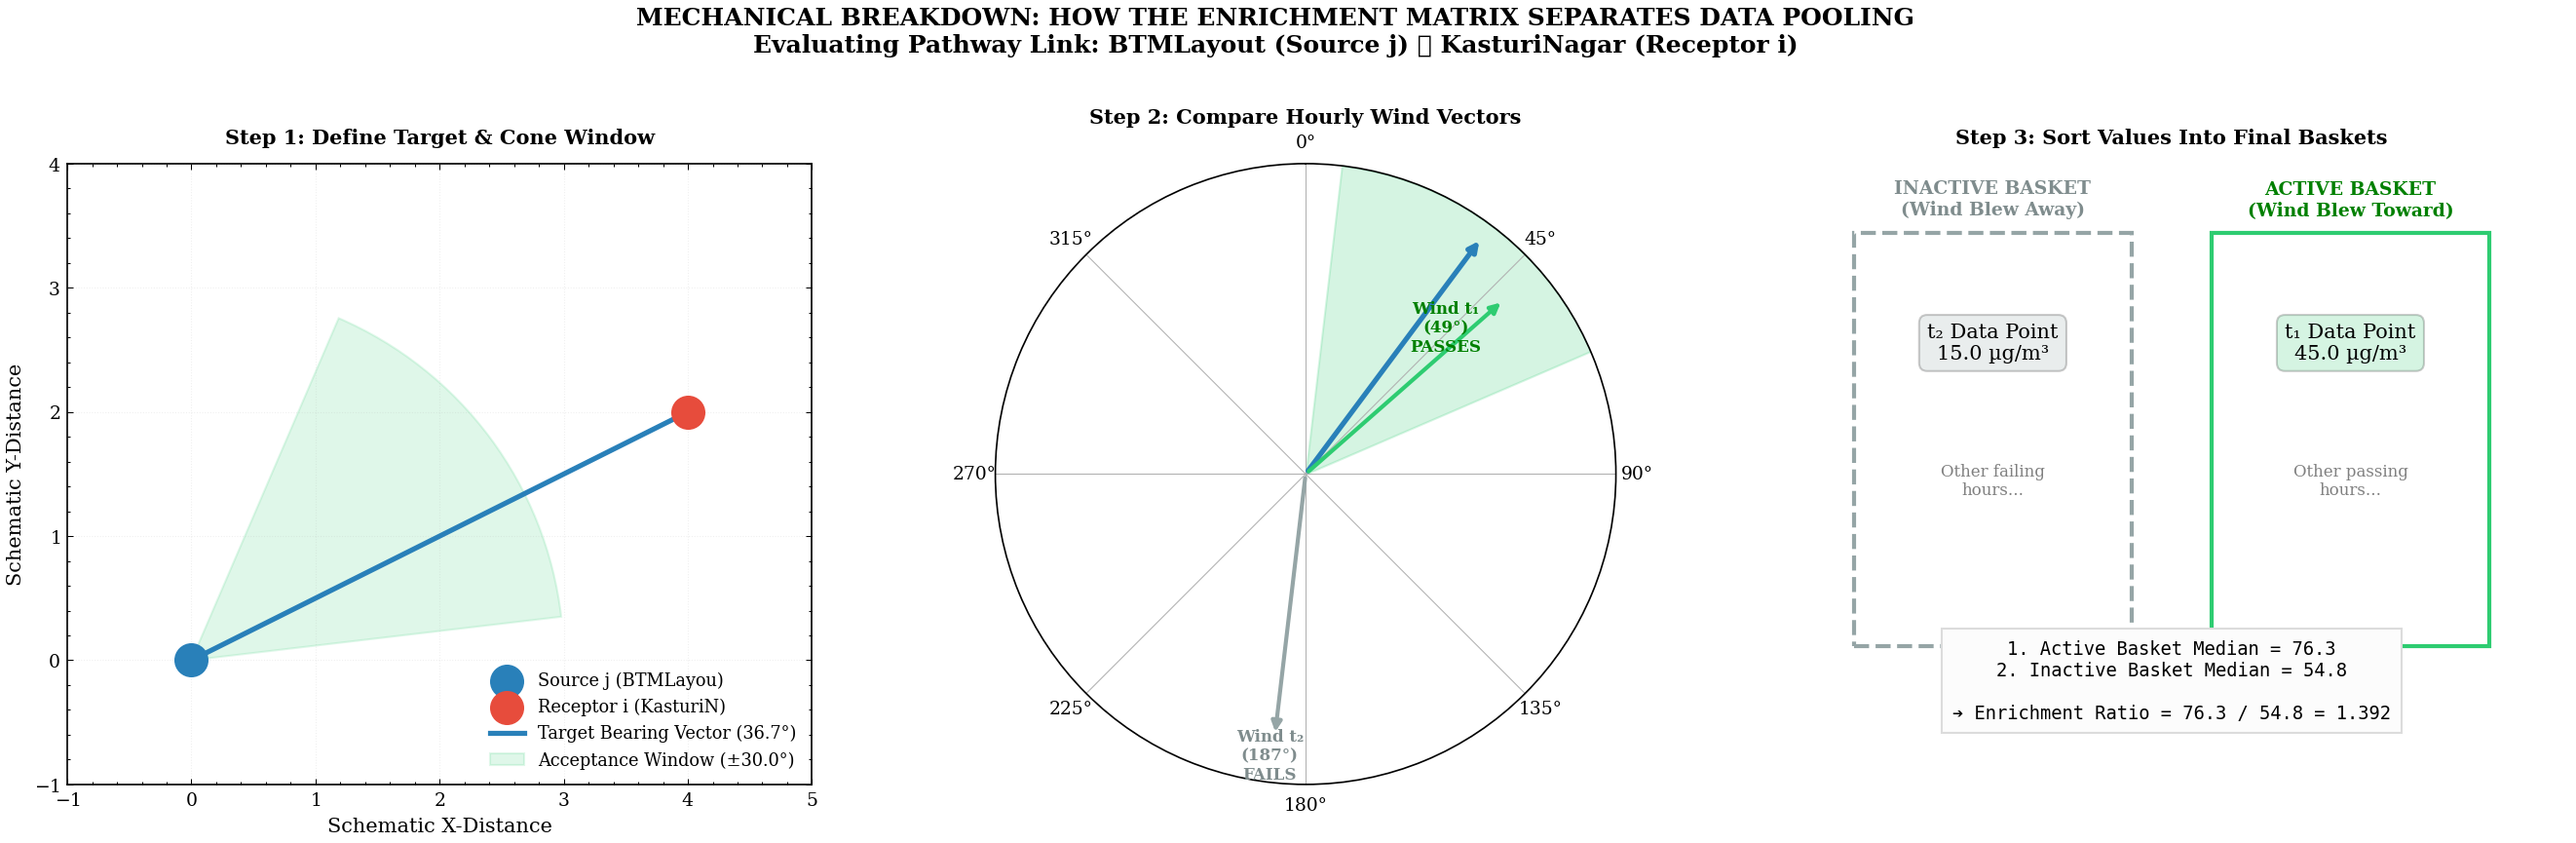

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# GEOMETRIC PASS-GATE MECHANICS VISUALIZATION
# What: Renders a 3-panel step-by-step schematic of the physical filter gate.
# Why:  Explicitly shows how individual wind vectors are tested against a cone
#       to group data into the Active vs. Inactive baskets for Enrichment.
# ─────────────────────────────────────────────────────────────────────────────
def visualize_filter_gate_mechanics(j, i, cone_deg=30):
    # Fetch core angles and station metadata
    b = bearing_mat[j, i]
    src_name = STATION_NAMES[j]
    rec_name = STATION_NAMES[i]

    # ── STEP A: MOCK TWO REPRESENTATIVE TIMESTAMPS FOR ILLUSTRATION ───────
    # Scenario 1: A direct-hit wind vector (e.g., pointing right along the bearing)
    wd_active = b + (cone_deg * 0.4)
    # Scenario 2: A missed-target wind vector (e.g., blowing away from the path)
    wd_inactive = (b + 150) % 360

    # Color variables matching style guidelines
    ACTIVE_C = "#2ecc71"  # Passing Green
    INACTIVE_C = "#95a5a6"  # Failing Grey
    BEARING_C = "#2980b9"  # Target Vector Blue

    # Setup a crisp, 3-panel horizontal layout
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    suptitle_text = (
        f"MECHANICAL BREAKDOWN: HOW THE ENRICHMENT MATRIX SEPARATES DATA POOLING\n"
        f"Evaluating Pathway Link: {src_name} (Source j) ➔ {rec_name} (Receptor i)"
    )
    plt.suptitle(suptitle_text, fontsize=12, fontweight="bold", y=1.02)

    # ─────────────────────────────────────────────────────────────────────────
    # PANEL 1: THE TARGET GEOMETRY GATEWAY
    # ─────────────────────────────────────────────────────────────────────────
    ax1 = axes[0]
    ax1.set_title(
        "Step 1: Define Target & Cone Window", fontsize=10, fontweight="bold", pad=10
    )

    # Draw Source and Receptor positions schematically
    ax1.scatter(
        0, 0, s=250, color=BEARING_C, zorder=5, label=f"Source j ({src_name[:8]})"
    )
    ax1.scatter(
        4, 2, s=250, color="#e74c3c", zorder=5, label=f"Receptor i ({rec_name[:8]})"
    )

    # Draw the baseline target vector line connecting them
    ax1.plot(
        [0, 4],
        [0, 2],
        color=BEARING_C,
        lw=2.5,
        ls="-",
        label=f"Target Bearing Vector ({b:.1f}°)",
    )

    # Illustrate the acceptance cone envelope surrounding the path
    # We simulate a visual wedge extending outwards from the source centerpoint
    cone_patch = mpatches.Wedge(
        (0, 0),
        3.0,
        b - cone_deg,
        b + cone_deg,
        color=ACTIVE_C,
        alpha=0.15,
        label=f"Acceptance Window (±{cone_deg}°)",
    )
    ax1.add_patch(cone_patch)

    # Clean up bounds and axes to focus purely on the geometry
    ax1.set_xlim(-1, 5)
    ax1.set_ylim(-1, 4)
    ax1.set_aspect("equal")
    ax1.grid(True, alpha=0.2, ls=":")
    ax1.legend(loc="lower right", fontsize=8.5)
    ax1.set_xlabel("Schematic X-Distance")
    ax1.set_ylabel("Schematic Y-Distance")

    # ─────────────────────────────────────────────────────────────────────────
    # PANEL 2: THE REAL-TIME WIND VECTOR PASS-FAIL TEST
    # ─────────────────────────────────────────────────────────────────────────
    # We use a polar plot here because wind measurements are physical circles!
    axes[1].remove()
    ax2 = fig.add_subplot(1, 3, 2, projection="polar")
    ax2.set_title(
        "Step 2: Compare Hourly Wind Vectors", fontsize=10, fontweight="bold", pad=20
    )

    ax2.set_theta_zero_location("N")
    ax2.set_theta_direction(-1)
    ax2.set_rticks([])

    # Render the static target cone boundary on the compass ring
    theta_cone = np.linspace(np.deg2rad(b - cone_deg), np.deg2rad(b + cone_deg), 50)
    ax2.fill_between(
        theta_cone, 0, 1, color=ACTIVE_C, alpha=0.2, label="Passing Sector"
    )

    # Draw Target Bearing Vector arrow
    ax2.annotate(
        "",
        xy=(np.deg2rad(b), 0.95),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="-|>", color=BEARING_C, lw=2.5),
    )

    # Draw Vector 1: The Passing Active Wind Example
    ax2.annotate(
        "",
        xy=(np.deg2rad(wd_active), 0.85),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="-|>", color=ACTIVE_C, lw=2.0, ls="-"),
    )
    ax2.text(
        np.deg2rad(wd_active),
        0.60,
        f"Wind t₁\n({wd_active:.0f}°)\nPASSES",
        color="green",
        fontweight="bold",
        fontsize=8,
        ha="center",
    )

    # Draw Vector 2: The Failing Inactive Wind Example
    ax2.annotate(
        "",
        xy=(np.deg2rad(wd_inactive), 0.85),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="-|>", color=INACTIVE_C, lw=2.0, ls="-"),
    )
    ax2.text(
        np.deg2rad(wd_inactive),
        0.99,
        f"Wind t₂\n({wd_inactive:.0f}°)\nFAILS",
        color="#7f8c8d",
        fontweight="bold",
        fontsize=8,
        ha="center",
    )

    ax2.set_ylim(0, 1)

    # ─────────────────────────────────────────────────────────────────────────
    # PANEL 3: ROUTING RECEPTOR DATA POINTS INTO MEDIAN BASKETS
    # ─────────────────────────────────────────────────────────────────────────
    ax3 = axes[2]
    ax3.set_title(
        "Step 3: Sort Values Into Final Baskets", fontsize=10, fontweight="bold", pad=10
    )

    # Draw two conceptual text container frames to look like physical sorting bins
    ax3.add_patch(
        mpatches.Rectangle(
            (0.1, 1), 0.35, 3, fill=False, edgecolor=INACTIVE_C, lw=2, ls="--"
        )
    )
    ax3.add_patch(
        mpatches.Rectangle((0.55, 1), 0.35, 3, fill=False, edgecolor=ACTIVE_C, lw=2)
    )

    ax3.text(
        0.275,
        4.1,
        "INACTIVE BASKET\n(Wind Blew Away)",
        ha="center",
        va="bottom",
        color="#7f8c8d",
        fontsize=9,
        fontweight="bold",
    )
    ax3.text(
        0.725,
        4.1,
        "ACTIVE BASKET\n(Wind Blew Toward)",
        ha="center",
        va="bottom",
        color="green",
        fontsize=9,
        fontweight="bold",
    )

    # Place representative data tokens dropping out from our simulated timestamps
    # Hour 1 (Active) routes to the active basket
    ax3.text(
        0.725,
        3.2,
        "t₁ Data Point\n45.0 µg/m³",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=ACTIVE_C, alpha=0.2),
    )
    ax3.text(
        0.725,
        2.2,
        "Other passing\nhours...",
        ha="center",
        va="center",
        color="gray",
        fontsize=8,
    )

    # Hour 2 (Inactive) routes to the inactive basket
    ax3.text(
        0.275,
        3.2,
        "t₂ Data Point\n15.0 µg/m³",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=INACTIVE_C, alpha=0.2),
    )
    ax3.text(
        0.275,
        2.2,
        "Other failing\nhours...",
        ha="center",
        va="center",
        color="gray",
        fontsize=8,
    )

    # Calculate illustrative final output metric string summary to display at floor level
    # Fetches real calculations computed dynamically in your upstream loops
    med_act = np.nanmedian(pair_data_store[(j, i)]["active"])
    med_inact = np.nanmedian(pair_data_store[(j, i)]["inactive"])
    ratio = enrichment_mat[i, j]

    math_summary = (
        f"1. Active Basket Median = {med_act:.1f}\n"
        f"2. Inactive Basket Median = {med_inact:.1f}\n\n"
        f"➔ Enrichment Ratio = {med_act:.1f} / {med_inact:.1f} = {ratio:.3f}"
    )
    ax3.text(
        0.5,
        0.1,
        math_summary,
        ha="center",
        va="bottom",
        transform=ax3.transAxes,
        bbox=dict(boxstyle="square,pad=0.6", facecolor="#fcfcfc", edgecolor="#dcdcdc"),
        fontsize=9,
        fontfamily="monospace",
    )

    # Eliminate default container frame markings from the sorting panel layout
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 4.5)
    ax3.axis("off")

    plt.tight_layout()
    plt.show()


visualize_filter_gate_mechanics(j=0, i=3, cone_deg=CONE_DEG)

## Block 6 — Mann-Whitney U Test

The enrichment ratio tells us *how much* concentration changes.
The Mann-Whitney U test tells us whether that change is **statistically real** or could be random noise.

**Why Mann-Whitney and not a t-test?**
PM2.5 data is not normally distributed — it has heavy tails from pollution spikes.
Mann-Whitney is non-parametric: it ranks values instead of assuming a distribution shape.

**`alternative='greater'`** means we only test if active windows have *higher* pollution.
We don't care if they are lower — that would be a different hypothesis.

- `p < 0.05` → the enrichment is real (less than 5% chance it's random)
- `p ≥ 0.05` → the enrichment could easily be coincidence → we discard this pair


In [49]:
# 20. Running Mann-Whitney U test for every (j → i) pair
pvalue_mat = np.full((N, N), np.nan)

for j in range(N):
    for i in range(N):
        if i == j:
            continue
        data = pair_data_store.get((j, i))
        if data is None:
            continue
        active_clean   = data["active"]
        inactive_clean = data["inactive"]
        if len(active_clean) > 0 and len(inactive_clean) > 0:
            _, p = stats.mannwhitneyu(active_clean, inactive_clean, alternative="greater")
            pvalue_mat[i, j] = p

# 21. Counting how many pairs pass the significance threshold
n_significant = int((pvalue_mat < ALPHA).sum())
display(pd.DataFrame({
    "Total pairs tested":          [int(np.isfinite(pvalue_mat).sum())],
    "Significant (p < 0.05)":      [n_significant],
    "Non-significant":             [int(np.isfinite(pvalue_mat).sum()) - n_significant],
}))

,Total pairs tested,Significant (p < 0.05),Non-significant
0,31,10,21


## Block 7 — Visualise: p-value Heatmap

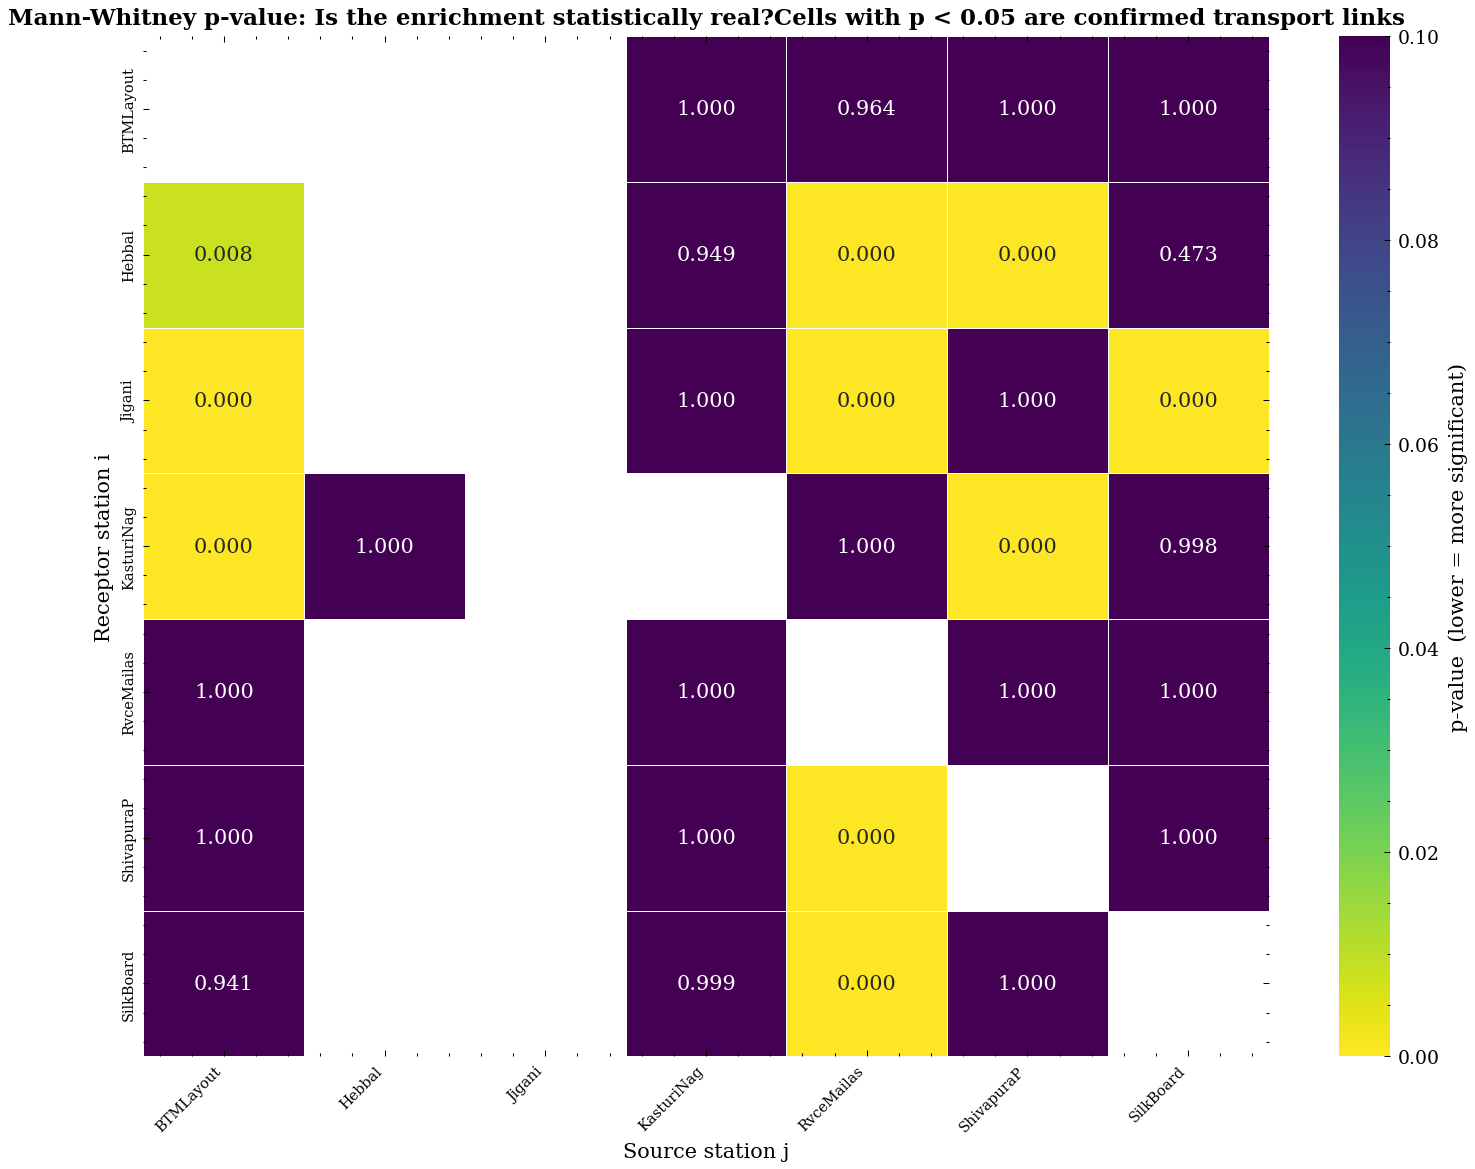

In [50]:
# 22. Heatmap of p-values — dark purple = very significant, yellow = not significant
# The diagonal is NaN (a station cannot be a source/receptor to itself)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pvalue_mat,
    mask=np.isnan(pvalue_mat),
    cmap="viridis_r",
    vmax=0.1,
    annot=True,
    fmt=".3f",
    cbar_kws={"label": "p-value  (lower = more significant)"},
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.3,
    linecolor="white",
    ax=ax,
)
ax.set_title(
    f"Mann-Whitney p-value: Is the enrichment statistically real?"
    f"Cells with p < {ALPHA} are confirmed transport links",
    fontweight="bold",
)
ax.set_xlabel("Source station j")
ax.set_ylabel("Receptor station i")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_pvalue_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 8 — Visualise: Enrichment Heatmap

/tmp/ipykernel_8696/3684786351.py:27: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_8696/3684786351.py:28: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  plt.savefig(PHASE3_OUT / "fig_enrichment_heatmap.png", dpi=150, bbox_inches="tight")
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


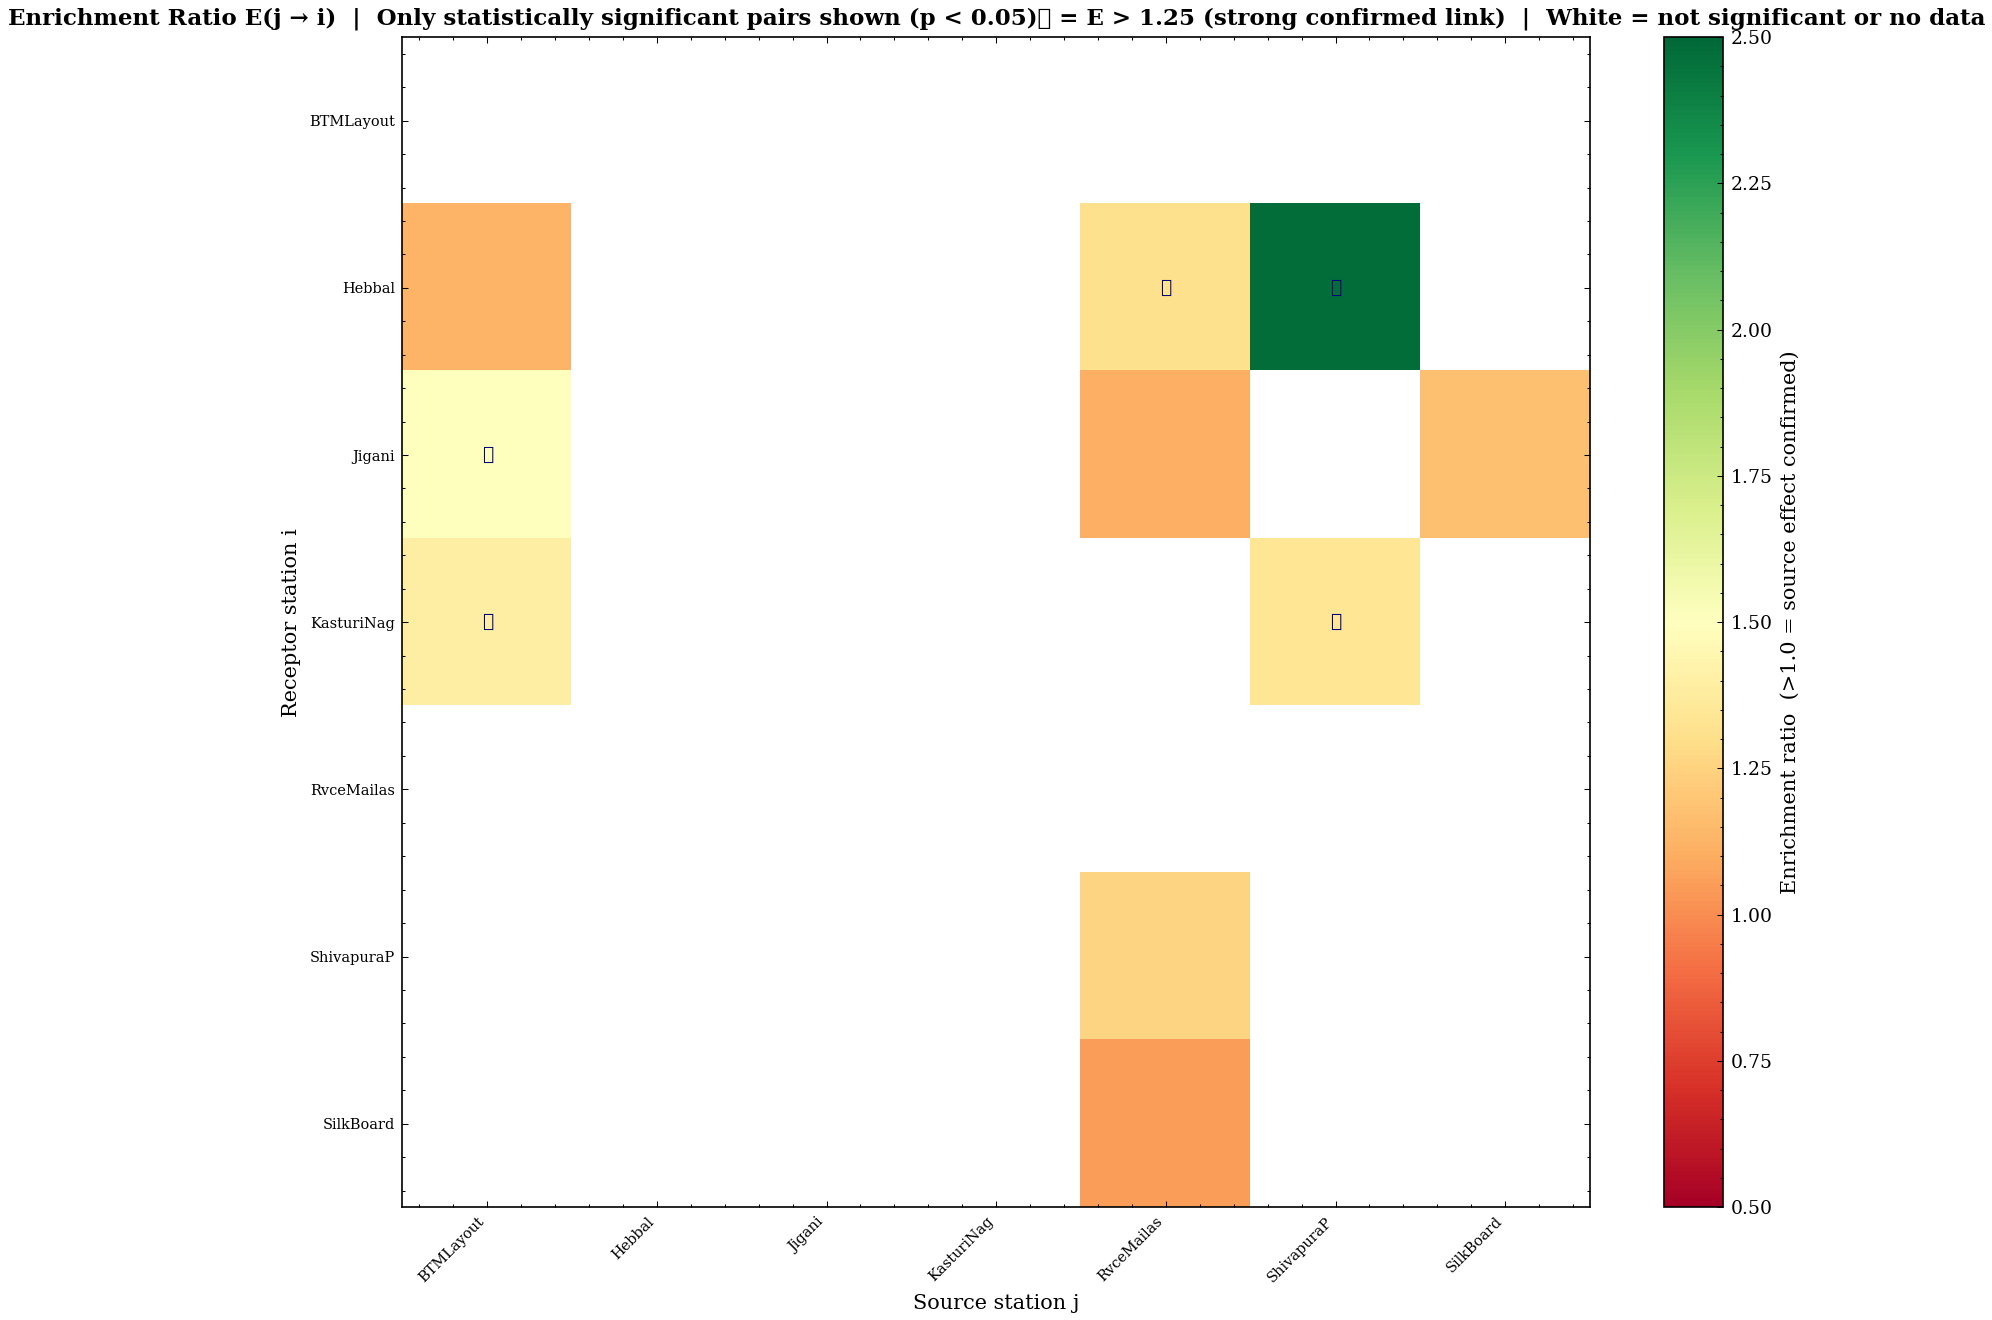

,Receptors significantly enriched
BTMLayout,2
ShivapuraPeenya,2
RvceMailasandra,1
Jigani,0
Hebbal,0
KasturiNagar,0
SilkBoard,0


In [51]:
# 23. Building the display matrix — only show pairs that passed the significance test
# Grey (NaN shown as white) = p ≥ 0.05, or insufficient active windows
E_display = np.where(pvalue_mat < ALPHA, enrichment_mat, np.nan)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(E_display, cmap="RdYlGn", vmin=0.5, vmax=2.5, aspect="auto")
plt.colorbar(im, ax=ax, label="Enrichment ratio  (>1.0 = source effect confirmed)")

ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel("Source station j")
ax.set_ylabel("Receptor station i")
ax.set_title(
    f"Enrichment Ratio E(j → i)  |  Only statistically significant pairs shown (p < {ALPHA})"
    f"★ = E > {ENRICHMENT_THRESHOLD} (strong confirmed link)  |  White = not significant or no data",
    fontweight="bold",
)

# 24. Marking strong links with a star so they are easy to spot
for i in range(N):
    for j in range(N):
        if np.isfinite(E_display[i, j]) and E_display[i, j] > ENRICHMENT_THRESHOLD:
            ax.text(j, i, "★", ha="center", va="center", fontsize=9, color="navy")

plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_enrichment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# 25. Summary of which source stations are confirmed to affect how many receptors
confirmed_source_counts = {
    STATION_NAMES[j]: int(
        (
            (pvalue_mat[:, j] < ALPHA) & (enrichment_mat[:, j] > ENRICHMENT_THRESHOLD)
        ).sum()
    )
    for j in range(N)
}
display(
    pd.DataFrame.from_dict(
        confirmed_source_counts,
        orient="index",
        columns=["Receptors significantly enriched"],
    ).sort_values("Receptors significantly enriched", ascending=False)
)

## Block 9 — Compare: Model T Matrix vs Empirical Fingerprint

This is the **core validation plot** of the entire research pipeline.

**Question**: Does the Gaussian Plume model (Notebook 2) agree with what the sensors actually show?

We scatter-plot T_mean[i,j] (model prediction) against E[i,j] (empirical enrichment).

- **High Spearman ρ** → model and data tell the same story → proceed to Bayesian inversion with confidence
- **Low Spearman ρ** → model is missing real pathways (street canyons, terrain) → note this as a limitation

We use **Spearman rank correlation** (not Pearson) because:
- T values span many orders of magnitude → log scale is needed
- Spearman only cares about *rank order*, not the absolute difference in scale


In [26]:
# 32. Gathering all valid (j→i) pairs where both T_mean and enrichment are finite
from pprint import pprint

T_mean = T_tensor.mean(axis=0)  # (N, N) — time-averaged transport matrix

T_vals, E_vals, pair_labels, abbrev_map = [], [], [], {}
for i in range(N):
    for j in range(N):
        if i == j:
            continue
        t = T_mean[i, j]
        e = enrichment_mat[i, j]
        if np.isfinite(e) and t > 0:
            T_vals.append(t)
            E_vals.append(e)
            src = STATION_NAMES[j][:3].upper()
            rec = STATION_NAMES[i][:3].upper()
            pair_labels.append(f"{src}→{rec}")
            abbrev_map[src] = STATION_NAMES[j]
            abbrev_map[rec] = STATION_NAMES[i]

T_vals = np.array(T_vals)
E_vals = np.array(E_vals)
rho, p_spear = stats.spearmanr(T_vals, E_vals)

pprint(
    {
        "Total pairs plotted": [len(T_vals)],
        "Spearman ρ": [f"{rho:.3f}"],
        "p-value": [f"{p_spear:.3e}"],
        "Interpretation": [
            "Model and data agree well — Gaussian plume captures real pathways"
            if rho > 0.4
            else "Moderate agreement — some pathways captured, some missed"
            if rho > 0.2
            else "Model and data diverge — local terrain/urban effects dominate"
        ],
    }
)

{'Interpretation': ['Model and data diverge — local terrain/urban effects '
                    'dominate'],
 'Spearman ρ': ['-0.079'],
 'Total pairs plotted': [31],
 'p-value': ['6.726e-01']}


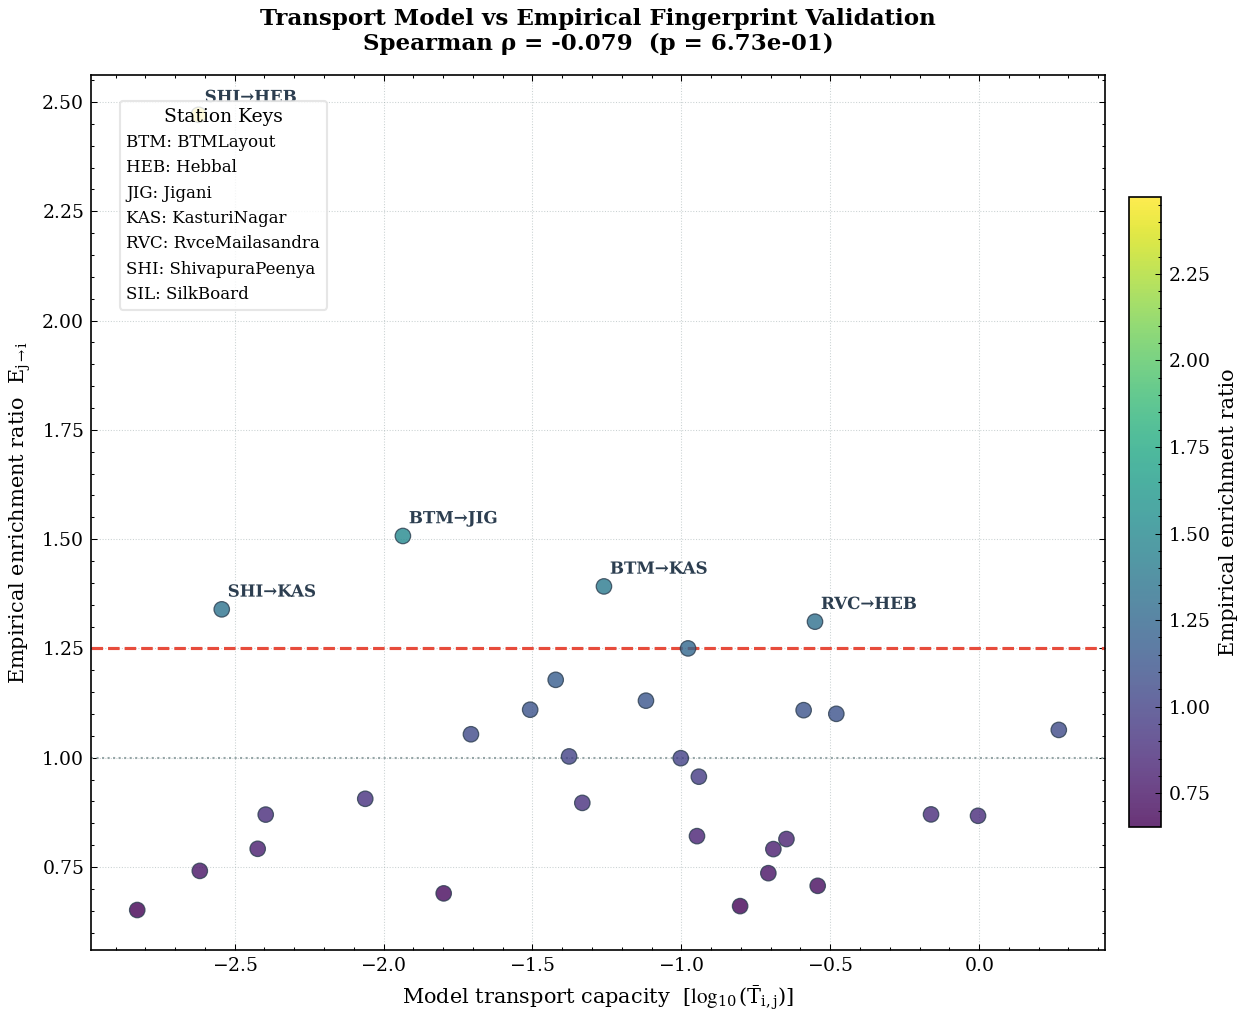

In [30]:
# 33. Scatter plot: log10(T_mean) vs enrichment ratio
# Points above the red dashed line are confirmed strong source-receptor links
log_T = np.log10(T_vals + 1e-10)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    log_T,
    E_vals,
    alpha=0.8,
    s=55,
    c=E_vals,
    cmap="viridis",
    edgecolor="#2c3e50",
    linewidths=0.6,
    zorder=3,
)
fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.72, label="Empirical enrichment ratio")

ax.axhline(
    ENRICHMENT_THRESHOLD,
    color="#e74c3c",
    lw=1.5,
    ls="--",
    label=f"Enrichment threshold ({ENRICHMENT_THRESHOLD})",
)
ax.axhline(1.0, color="#95a5a6", lw=1.0, ls=":", label="No enrichment (E = 1.0)")

# 34. Labelling only the pairs that exceed the enrichment threshold
for t_log, e_val, label in zip(log_T, E_vals, pair_labels):
    if e_val > ENRICHMENT_THRESHOLD:
        txt = ax.text(
            t_log + 0.02,
            e_val + 0.02,
            label,
            fontsize=8,
            fontweight="bold",
            color="#2c3e50",
            ha="left",
            va="bottom",
            zorder=5,
        )
        txt.set_path_effects(
            [pe.withStroke(linewidth=2.5, foreground="white", alpha=0.9)]
        )

ax.set_xlabel(r"Model transport capacity  [$\log_{10}(\bar{T}_{i,j})$]")
ax.set_ylabel(r"Empirical enrichment ratio  $E_{j \rightarrow i}$")
ax.set_title(
    f"Transport Model vs Empirical Fingerprint Validation\n"
    f"Spearman ρ = {rho:.3f}  (p = {p_spear:.2e})",
    fontweight="bold",
    pad=12,
)

# 35. Station abbreviation key in the legend
mapping_handles = [
    mpatches.Patch(color="none", label=f"{short}: {long}")
    for short, long in sorted(abbrev_map.items())
]
ax.legend(
    handles=mapping_handles,
    title="Station Keys",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    handlelength=0,
    handletextpad=0,
)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.5, color="#95a5a6")
plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_model_vs_fingerprint.png", bbox_inches="tight", dpi=300)
plt.show()

## Block 10 — Confirmed Source-Receptor Network

In [39]:
# 36. Building a directed graph using only the statistically confirmed links
# A link is confirmed when: E > threshold AND p < alpha AND n_active >= minimum
G_conf = nx.DiGraph()
confirmed_links = []

for i in range(N):
    for j in range(N):
        if i == j:
            continue
        e = enrichment_mat[i, j]
        p = pvalue_mat[i, j]
        n = n_active_mat[i, j]
        if np.isfinite(e) and e > ENRICHMENT_THRESHOLD and np.isfinite(p) and p < ALPHA and n >= MIN_ACTIVE_WINDOWS:
            G_conf.add_edge(STATION_NAMES[j], STATION_NAMES[i], weight=e, pval=p)
            confirmed_links.append({
                "source":      STATION_NAMES[j],
                "receptor":    STATION_NAMES[i],
                "enrichment":  round(e, 3),
                "p_value":     round(p, 4),
                "n_active":    n,
                "distance_km": round(distance_mat[j, i], 1),
            })

display(pd.DataFrame(confirmed_links).sort_values("enrichment", ascending=False).reset_index(drop=True))

,source,receptor,enrichment,p_value,n_active,distance_km
0,ShivapuraPeenya,Hebbal,2.471,0.0,10825,8.5
1,BTMLayout,Jigani,1.507,0.0,6566,15.1
2,BTMLayout,KasturiNagar,1.392,0.0,99,12.5
3,ShivapuraPeenya,KasturiNagar,1.339,0.0,12062,17.1
4,RvceMailasandra,Hebbal,1.311,0.0,1941,15.0


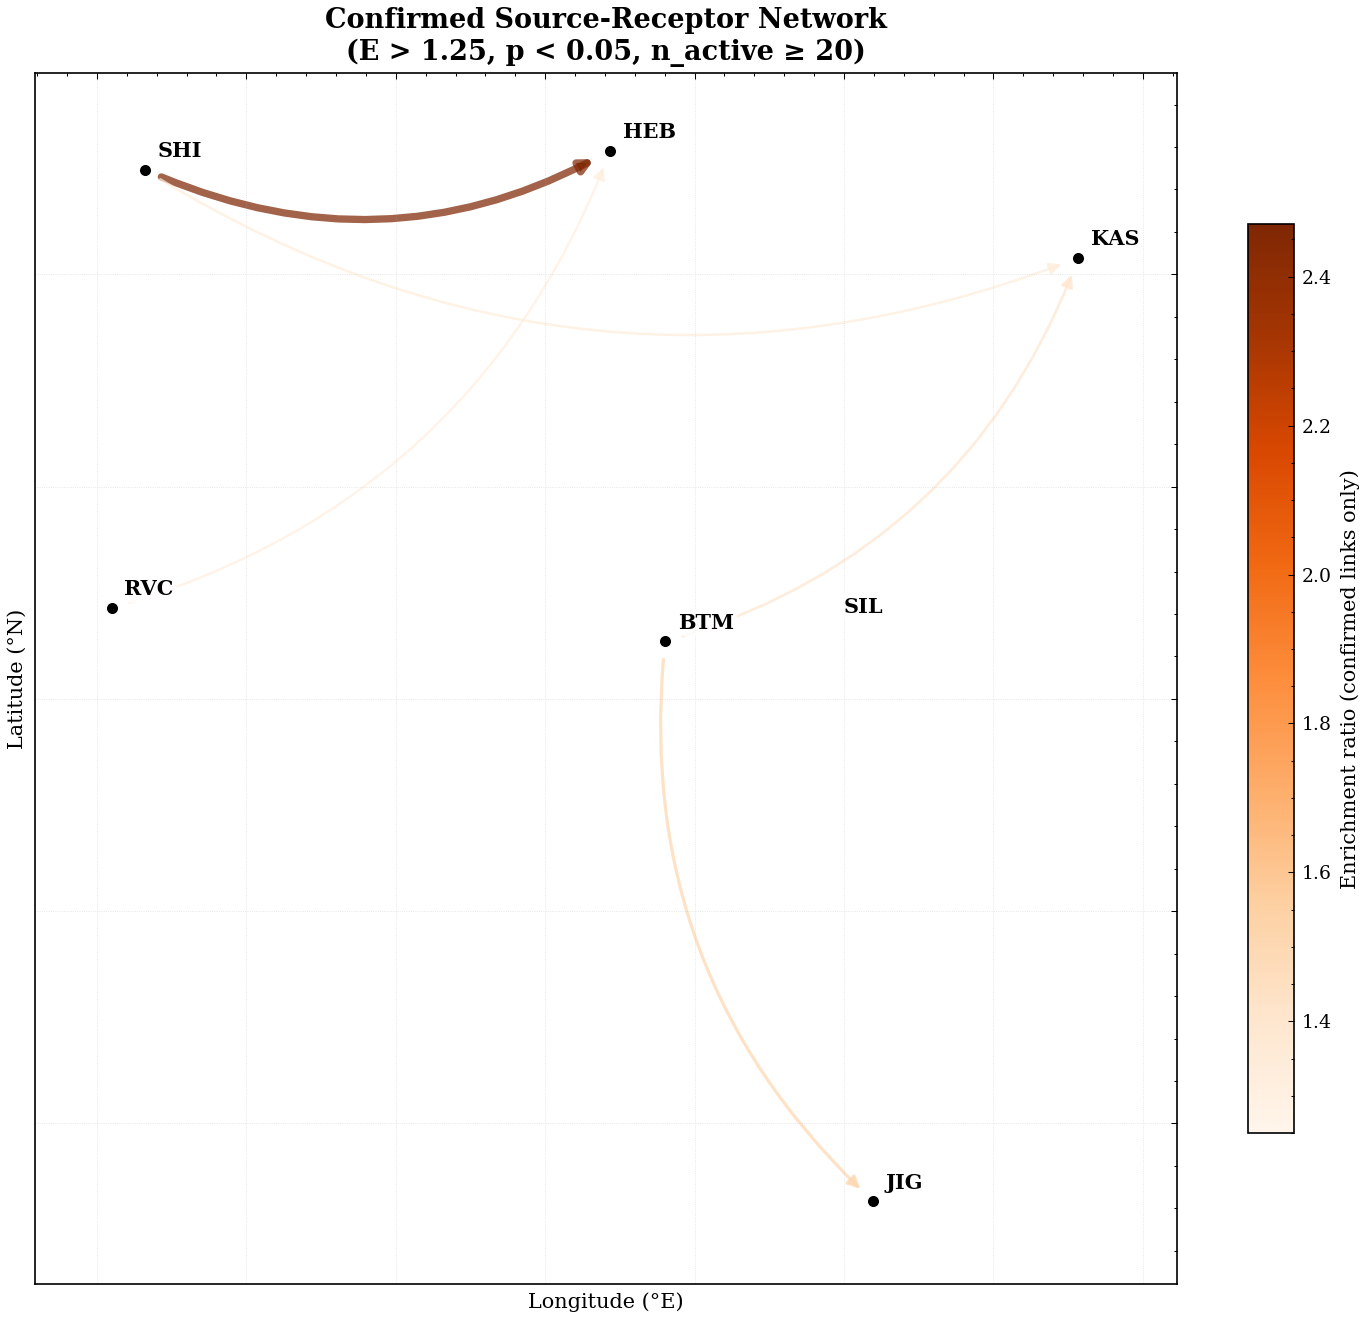

In [40]:
# 37. Plotting the confirmed network on a geographic map
# Arrow colour and thickness both encode enrichment strength
pos_map = {
    row["station_name"]: (row["longitude"], row["latitude"])
    for _, row in stations_df.iterrows()
    if row["station_name"] in STATION_NAMES
}

edges = list(G_conf.edges())
e_weights = (
    np.array([G_conf[u][v]["weight"] for u, v in edges]) if edges else np.array([])
)
norm_e = mcolors.Normalize(
    vmin=ENRICHMENT_THRESHOLD, vmax=e_weights.max() if len(e_weights) else 2
)
cmap_e = plt.cm.Oranges

fig, ax = plt.subplots(figsize=(10, 9))
for (u, v), w in zip(edges, e_weights):
    nx.draw_networkx_edges(
        G_conf,
        pos_map,
        edgelist=[(u, v)],
        edge_color=[cmap_e(norm_e(w))],
        width=1.0 + 2.5 * norm_e(w),
        alpha=0.72,
        arrows=True,
        arrowsize=12,
        arrowstyle="-|>",
        connectionstyle="arc3,rad=0.25",
        ax=ax,
        min_source_margin=8,
        min_target_margin=8,
    )
nx.draw_networkx_nodes(
    G_conf,
    pos_map,
    node_size=35,
    node_color="black",
    edgecolors="white",
    linewidths=0.6,
    ax=ax,
)
for station, (lon, lat) in pos_map.items():
    ax.annotate(
        station[:3].upper(),
        xy=(lon, lat),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85
        ),
    )
sm = plt.cm.ScalarMappable(cmap=cmap_e, norm=norm_e)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Enrichment ratio (confirmed links only)", shrink=0.75)
ax.set_title(
    f"Confirmed Source-Receptor Network\n"
    f"(E > {ENRICHMENT_THRESHOLD}, p < {ALPHA}, n_active ≥ {MIN_ACTIVE_WINDOWS})",
    fontweight="bold",
    fontsize=13,
)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.4)
plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_confirmed_network.png", bbox_inches="tight", dpi=300)
plt.show()

## Block 12 — Export for Notebook 4 (Bayesian Inversion)

In [41]:
# 38. Saving enrichment and p-value matrices for Notebook 4
# The Bayesian inversion uses the enrichment matrix as a data-driven prior:
# stations that empirically enrich many receptors get a higher prior emission weight
np.save(PHASE3_OUT / "enrichment_matrix.npy", enrichment_mat)
np.save(PHASE3_OUT / "pvalue_matrix.npy", pvalue_mat)
np.save(PHASE3_OUT / "n_active_matrix.npy", n_active_mat)

pd.DataFrame(enrichment_mat, index=STATION_NAMES, columns=STATION_NAMES).to_parquet(
    PHASE3_OUT / "enrichment_matrix.parquet"
)

display(
    pd.DataFrame(
        {
            "File": [
                "enrichment_matrix.npy / .parquet",
                "pvalue_matrix.npy",
                "n_active_matrix.npy",
                "bearing_matrix.parquet",
                "distance_matrix.parquet",
            ],
            "Contents": [
                f"E[i,j] enrichment ratios — {N}x{N}",
                f"Mann-Whitney p-values — {N}x{N}",
                f"Count of active wind windows — {N}x{N}",
                f"Compass bearings j→i — {N}x{N}",
                f"Inter-station distances (km) — {N}x{N}",
            ],
        }
    )
)

,File,Contents
0,enrichment_matrix.npy / .parquet,"E[i,j] enrichment ratios — 7x7"
1,pvalue_matrix.npy,Mann-Whitney p-values — 7x7
2,n_active_matrix.npy,Count of active wind windows — 7x7
3,bearing_matrix.parquet,Compass bearings j→i — 7x7
4,distance_matrix.parquet,Inter-station distances (km) — 7x7
